# MaxCal barrier tilt: interactive demo

This notebook uses the test datasets to show, step by step, what the `maxcal` tools do (one section per executable):

1. **Attempts.** Trajectories are decomposed into failed and successful attempts at an interface Q‡.
2. **Reweighting.** Each trajectory gets the MaxCal weight $w \propto c^{k}$; you can see what that does to the folding-time distribution, and why it saturates.
3. **Stitching.** The same tilted ensemble is sampled generatively, and Poisson statistics emerge.
4. **Validation.** Stitched model data are compared with a ground truth that has a higher barrier, including where Q‡ must be placed, and the original and stitched CDFs are shown side by side (5b).
5. **Joint mode.** Forward and backward runs: kinetic ΔG and transition-path time-reversal symmetry.
6. **Transition state.** Where the corrected TS sits, and why it depends on where the missing barrier is assumed to be.
7. **Decision map.** The stitching test over the (Q‡, λ) plane, and why the TS must lie between Q‡ and Qf.

Sliders need `ipywidgets` (`pip install -e ".[demo]"`). Without it, each interactive cell shows a static figure for a few parameter values instead. Sliders recompute when you **release** them, and a *computing…* note appears while the kernel is busy.

**If a cell seems idle:**
- **No controls appear at all.** The notebook front end is not rendering widgets. Install `ipywidgets` in the environment that runs Jupyter, not only in the kernel. In VS Code, update the Jupyter extension. Or set `MAXCAL_DEMO_STATIC=1` before starting Jupyter to get static figures.
- **Controls appear but nothing updates.** The kernel may still be busy with an earlier cell (see the kernel indicator). Wait, or interrupt it. See the README for the derivations (§ numbers below refer to it).

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path[:0] = [ROOT, os.path.join(ROOT, "tests")]
import importlib
import maxcal as mp                    # shared functions (attempts, stitch, cv_curve, ...)
from maxcal import joint as mj
import langevin as L
import synthetic as S
# re-running this cell picks up code changes (e.g. after git pull / git am) without a restart
for _mod in (mp, mj, L, S):
    importlib.reload(_mod)
_missing = [f for f in ("committor_frames", "ts_location", "ks_heatmap", "stitch")
            if not hasattr(mp, f)]
if _missing or not os.path.abspath(mp.__file__).startswith(ROOT):
    raise ImportError(f"maxcal imported from {mp.__file__} is not this repository's "
                      f"current version (missing: {_missing}). Run `pip install -e .` from the "
                      f"repository root and restart the kernel.")
print("using", mp.__file__)

# MAXCAL_DEMO_STATIC=1 forces static figures (used to render the committed copy)
try:
    import ipywidgets as W
    HAVE_WIDGETS = not os.environ.get("MAXCAL_DEMO_STATIC")
except ImportError:
    HAVE_WIDGETS = False

def _widget(name, spec, default):
    # slider/dropdown that updates only when released (no backlog of recomputations)
    if isinstance(spec, list):
        return W.Dropdown(options=spec, value=default if default in spec else spec[0],
                          description=name)
    lo, hi, step = spec
    cls = W.IntSlider if all(isinstance(v, int) for v in spec) else W.FloatSlider
    return cls(min=lo, max=hi, step=step, value=default, description=name,
               continuous_update=False, style={"description_width": "initial"})


def explore(fn, static, **sliders):
    # interactive controls if ipywidgets is available, otherwise static calls;
    # recomputes only when a slider is released and shows 'computing…' while busy
    if not HAVE_WIDGETS:
        for kw in static:
            fn(**kw)
        return
    import inspect
    defaults = {k: v.default for k, v in inspect.signature(fn).parameters.items()}
    controls = {k: _widget(k, v, defaults[k]) for k, v in sliders.items() if v is not None}
    status = W.HTML()
    out = W.Output()

    def run(**kw):
        status.value = "<i>computing…</i>"
        with out:
            out.clear_output(wait=True)
            fn(**kw)
        status.value = ""
    W.interactive_output(run, controls)
    display(W.VBox([W.HBox(list(controls.values())), status, out]))

import time, hashlib, json
CACHE = os.path.join(ROOT, "notebooks", ".cache")

def simulate(label, **kw):
    # L.run_many with an on-disk cache: the first run simulates (and reports how long
    # it took), later runs, and kernel restarts, load in well under a second
    key = hashlib.sha1(json.dumps(kw, sort_keys=True, default=str).encode()).hexdigest()[:12]
    path = os.path.join(CACHE, f"{label}_{key}.npz")
    if os.path.exists(path):
        z = np.load(path)
        return np.split(z["q"], np.cumsum(z["n"])[:-1]), float(z["dt"])
    t0 = time.time()
    print(f"  simulating {label} ({kw.get('n')} trajectories)…", flush=True)
    Qs, dt = L.run_many(**kw)
    os.makedirs(CACHE, exist_ok=True)
    np.savez(path, q=np.concatenate(Qs), n=[len(q) for q in Qs], dt=dt)
    print(f"  done in {time.time() - t0:.1f} s (cached for next time)", flush=True)
    return Qs, dt

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
QU, QF = 0.3, 0.8
print("widgets:", HAVE_WIDGETS)

using /home/claude/repo/maxcal/__init__.py
widgets: False


## 1. Data

We use two datasets.
- **`langevin`**: 100 overdamped Langevin trajectories on a low-barrier double well (barrier 0.8 kT at Q = 0.55), started below the unfolded minimum and stopped at folding. This is the same data as the regression test.
- **`synthetic`**: hand-built trajectories from `tests/synthetic.py`, in which pure reweighting succeeds (§2.4). They exist only to exercise the code, not as a physical model.

In [2]:
def to_trajs(Qs, dt):
    out = []
    for i, q in enumerate(Qs):
        fold, fails = mp.parse_traj(q, QU, QF)
        out.append(dict(path=str(i), q=q, dt=dt, n=q.size, fold=fold, fails=fails))
    return out

# Langevin regression data (same generator and seeds as tests/test_regtest.py)
lang_Q = [L.run_one(np.random.default_rng([2024, i]))[0] for i in range(100)]
lang_dt = L.run_one(np.random.default_rng([2024, 0]))[1]

# synthetic data where reweighting reaches CV = 1
import tempfile, glob
tmp = tempfile.mkdtemp()
S.write_reweight_set(tmp)
syn_Q = [np.loadtxt(f)[:, 1] for f in sorted(glob.glob(os.path.join(tmp, "*.xvg")))]

DATA = {"langevin": to_trajs(lang_Q, lang_dt), "synthetic": to_trajs(syn_Q, 1.0)}
DEFAULT_QTS = {"langevin": 0.45, "synthetic": 0.45}
for k, v in DATA.items():
    print(f"{k:10s}: {len(v)} trajectories, all folded: {all(t['fold'] is not None for t in v)}")

langevin  : 100 trajectories, all folded: True
synthetic : 240 trajectories, all folded: True


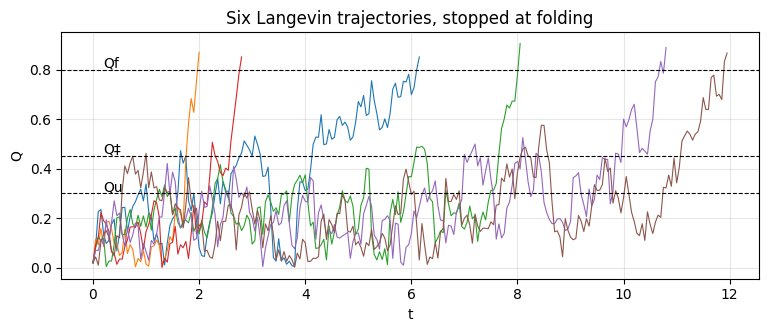

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for q in lang_Q[:6]:
    ax.plot(np.arange(q.size) * lang_dt, q, lw=0.8)
for y, lab in [(QU, "Qu"), (0.45, "Q‡"), (QF, "Qf")]:
    ax.axhline(y, color="k", ls="--", lw=0.8); ax.text(0.2, y + 0.01, lab)
ax.set_xlabel("t"); ax.set_ylabel("Q"); ax.set_title("Six Langevin trajectories, stopped at folding")
plt.show()

## 2. Attempts at Q‡

An **attempt** is an excursion out of U (Q < Qu) that gets past Q‡; it **fails** if it returns to U before reaching Qf. Moving Q‡ changes what counts as an attempt:
- the success probability per attempt, p, grows as Q‡ approaches Qf;
- independent attempts give a **geometric** distribution of the number of failures k (§2.1).

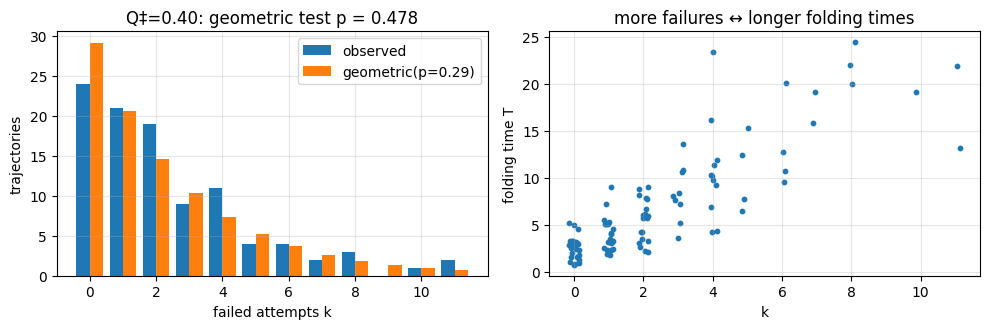

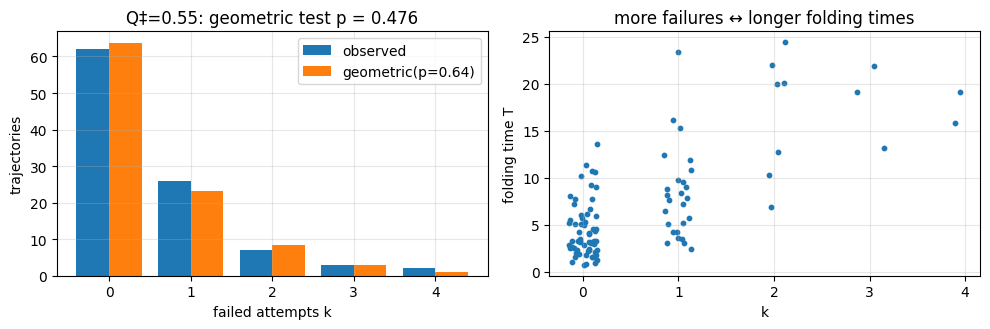

In [4]:
def show_attempts(dataset="langevin", qts=0.45):
    A = mp.attempts(DATA[dataset], qts, 0.0, False)
    k, done = A["k"], A["done"]
    p = mp.success_prob(k, done)
    gp, _ = mp.geometric_test(k[done])
    fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
    kk = np.arange(k.max() + 1)
    axs[0].bar(kk - 0.2, np.bincount(k, minlength=kk.size), width=0.4, label="observed")
    axs[0].bar(kk + 0.2, k.size * p * (1 - p) ** kk, width=0.4, label=f"geometric(p={p:.2f})")
    axs[0].set_xlabel("failed attempts k"); axs[0].set_ylabel("trajectories")
    axs[0].set_title(f"Q‡={qts:.2f}: geometric test p = {gp:.3f}" if np.isfinite(gp) else
                     f"Q‡={qts:.2f}: too few distinct k to test")
    axs[0].legend()
    axs[1].scatter(k + np.random.default_rng(0).uniform(-0.15, 0.15, k.size), A["T"], s=10)
    axs[1].set_xlabel("k"); axs[1].set_ylabel("folding time T")
    axs[1].set_title("more failures ↔ longer folding times")
    plt.tight_layout(); plt.show()

explore(show_attempts,
        static=[dict(dataset="langevin", qts=q) for q in (0.4, 0.55)],
        dataset=["langevin", "synthetic"],
        qts=(0.32, 0.78, 0.01) if HAVE_WIDGETS else None)

## 3. Reweighting: $w \propto c^{k}$

The MaxCal tilt multiplies the odds of every attempt by $e^{-\lambda}$. For a trajectory with k failures this gives the weight $w \propto c^{k+1}e^{-\lambda}$ with $c = 1/[1-p(1-e^{-\lambda})]$ (§2.3). Move λ and watch four things:
- **Weights.** They grow geometrically with k but **saturate** at $(1-p)^{-k}$ (dashed line).
- **N_eff.** It drops as the weight concentrates on a few trajectories.
- **CV on the Langevin data.** It *falls*: upweighting sums of more cycles makes the times more regular (§2.4).
- **CV on the synthetic data.** It crosses 1 at a finite λ*.

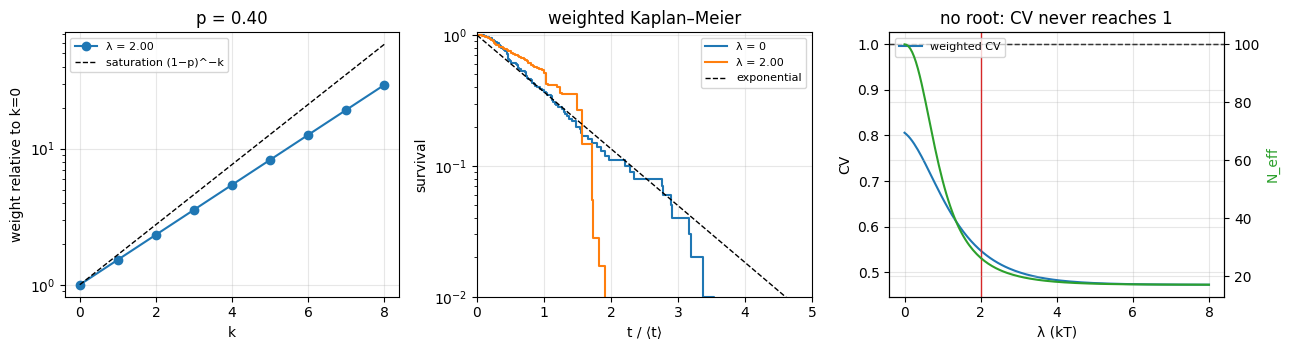

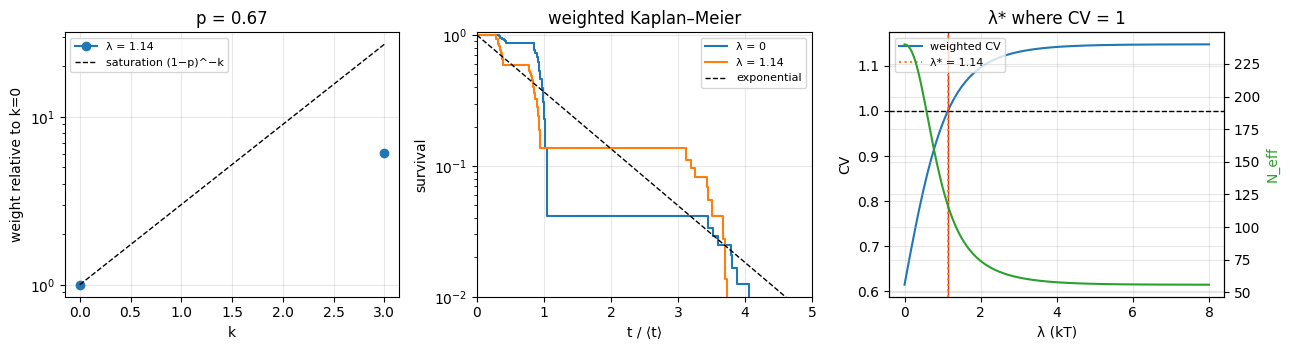

In [5]:
LAMS = np.linspace(0, 8, 161)

def show_reweight(dataset="langevin", qts=0.45, lam=1.0):
    A = mp.attempts(DATA[dataset], qts, 0.0, False)
    k, T, done = A["k"], A["T"], A["done"]
    p = mp.success_prob(k, done)
    cv, neff = mp.cv_curve(LAMS, k, T, done, p)
    lam_star = mp.first_crossing(LAMS, cv)
    w = np.exp(mp.log_weights(lam, k, done, p)[0])

    fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
    kk = np.arange(k.max() + 1)
    wk = np.array([w[k == j].mean() / w[k == 0].mean() if np.any(k == j) else np.nan for j in kk])
    axs[0].semilogy(kk, wk, "o-", label=f"λ = {lam:.2f}")
    axs[0].semilogy(kk, (1 - p) ** -kk, "k--", lw=1, label="saturation (1−p)^−k")
    axs[0].set_xlabel("k"); axs[0].set_ylabel("weight relative to k=0"); axs[0].legend(fontsize=8)
    axs[0].set_title(f"p = {p:.2f}")

    x = np.linspace(0, 5, 200)
    for wt, lab in [(np.full(k.size, 1 / k.size), "λ = 0"), (w / w.sum(), f"λ = {lam:.2f}")]:
        ts, Sv, _ = mp.weighted_km(T, done, wt)
        tau = np.sum(wt * T) / np.sum(wt * done)
        axs[1].step(np.r_[0, ts / tau], np.r_[1, Sv], where="post", label=lab)
    axs[1].semilogy(x, np.exp(-x), "k--", lw=1, label="exponential")
    axs[1].set_ylim(1e-2, 1.05); axs[1].set_xlim(0, 5)
    axs[1].set_xlabel("t / ⟨t⟩"); axs[1].set_ylabel("survival"); axs[1].legend(fontsize=8)
    axs[1].set_title("weighted Kaplan–Meier")

    axs[2].plot(LAMS, cv, label="weighted CV"); axs[2].axhline(1, color="k", ls="--", lw=1)
    ax2 = axs[2].twinx(); ax2.plot(LAMS, neff, color="C2", label="N_eff"); ax2.set_ylabel("N_eff", color="C2")
    axs[2].axvline(lam, color="C3", lw=1)
    if np.isfinite(lam_star):
        axs[2].axvline(lam_star, color="C1", ls=":", label=f"λ* = {lam_star:.2f}")
    axs[2].set_xlabel("λ (kT)"); axs[2].set_ylabel("CV"); axs[2].legend(fontsize=8, loc="upper left")
    axs[2].set_title("λ* where CV = 1" if np.isfinite(lam_star) else "no root: CV never reaches 1")
    plt.tight_layout(); plt.show()

explore(show_reweight,
        static=[dict(dataset="langevin", lam=2.0), dict(dataset="synthetic", lam=1.14)],
        dataset=["langevin", "synthetic"],
        qts=(0.32, 0.78, 0.01) if HAVE_WIDGETS else None,
        lam=(0.0, 8.0, 0.05) if HAVE_WIDGETS else None)

## 4. Stitching: sampling the tilted ensemble

Instead of reweighting the observed trajectories, stitching builds new folding times. Each one is a geometric(p′) number of resampled failure cycles plus one resampled success segment (§2.5). Because the number of attempts is no longer limited to what was observed, the geometric tail of a higher barrier appears. By Rényi's theorem, CV → 1 as p′ → 0.

The median KS p-value is computed on subsamples of the original size, so the test has the same power as on the data. Note that Poisson statistics emerge for *any* model with independent attempts once λ is large enough. That is why the Poisson threshold is only a lower bound on the tilt (§2.6).

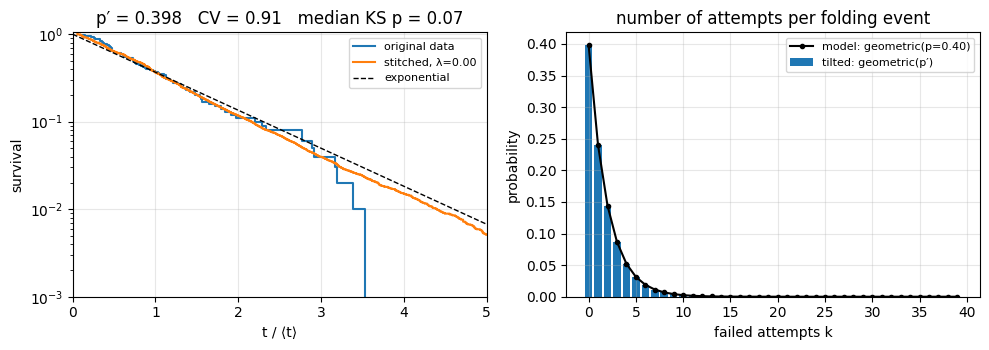

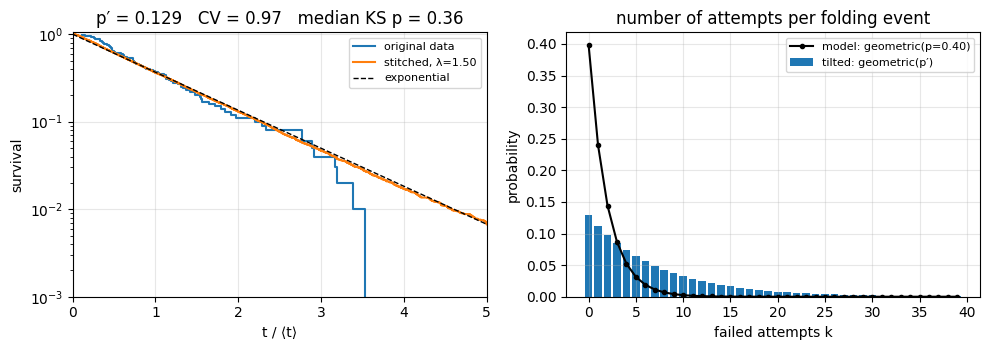

In [6]:
def show_stitch(dataset="langevin", qts=0.45, lam=1.0, seed=0):
    A = mp.attempts(DATA[dataset], qts, 0.0, False)
    k, done = A["k"], A["done"]
    p = mp.success_prob(k, done); pp = mp.tilted_p(p, lam)
    rng = np.random.default_rng(seed)
    if A["fail_pool"].size == 0:
        print("empty failure pool at this Q‡ (no failed attempts get past it)"); return
    t = mp.stitch(pp, A["fail_pool"], A["succ_pool"], 10000, rng)
    sub = rng.choice(t, size=(200, k.size))
    null = mp.null_D(k.size)
    pv = (np.sum(null[None, :] >= mp.D_rows(sub)[:, None], axis=1) + 1) / (null.size + 1)

    fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
    x = np.linspace(0, 5, 200)
    T = A["T"][done]; Ts = np.sort(T) / T.mean()
    axs[0].step(Ts, 1 - np.arange(1, Ts.size + 1) / Ts.size, where="post", label="original data")
    ts = np.sort(t) / t.mean()
    axs[0].step(ts, 1 - np.arange(1, ts.size + 1) / ts.size, where="post", label=f"stitched, λ={lam:.2f}")
    axs[0].semilogy(x, np.exp(-x), "k--", lw=1, label="exponential")
    axs[0].set_ylim(1e-3, 1.05); axs[0].set_xlim(0, 5); axs[0].legend(fontsize=8)
    axs[0].set_xlabel("t / ⟨t⟩"); axs[0].set_ylabel("survival")
    axs[0].set_title(f"p′ = {pp:.3f}   CV = {t.std() / t.mean():.2f}   median KS p = {np.median(pv):.2f}")
    kk = np.arange(0, 40)
    axs[1].bar(kk, pp * (1 - pp) ** kk, label="tilted: geometric(p′)")
    axs[1].plot(kk, p * (1 - p) ** kk, "k.-", label=f"model: geometric(p={p:.2f})")
    axs[1].set_xlabel("failed attempts k"); axs[1].set_ylabel("probability"); axs[1].legend(fontsize=8)
    axs[1].set_title("number of attempts per folding event")
    plt.tight_layout(); plt.show()

explore(show_stitch,
        static=[dict(lam=0.0), dict(lam=1.5)],
        dataset=["langevin", "synthetic"],
        qts=(0.32, 0.78, 0.01) if HAVE_WIDGETS else None,
        lam=(0.0, 6.0, 0.05) if HAVE_WIDGETS else None,
        seed=(0, 20, 1) if HAVE_WIDGETS else None)

## 5. Validation against a known answer

Now the higher barrier is actually simulated. The **truth** is the same double well plus a Gaussian bump of height ΔB on the barrier top, so the basins are unchanged. This is exactly the assumption behind the tilt: correct sampling, underestimated barrier.

For each Q‡, the **true** p′ is taken from the truth's own attempt statistics. Stitching the *model's* segments with that p′ should reproduce the truth's folding-time distribution. Move Q‡ to see where this works:
- **At the foot of the barrier (Q‡ ≈ 0.4):** stitched and true distributions agree.
- **On the barrier top (Q‡ ≈ 0.55):** the missing barrier also changes how often Q‡ is reached, and the prediction fails (§2.8).

The panel title also shows the true λ next to ΔB. λ is an effective log-odds shift, not the barrier height (§2.7).

model and ground-truth trajectories (slow only the first time; then cached):


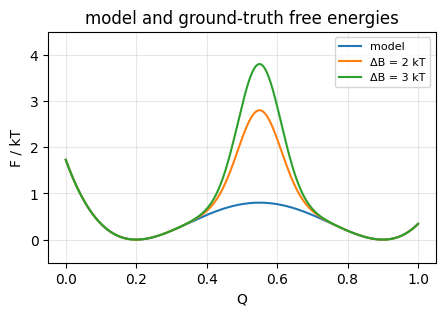

In [7]:
print("model and ground-truth trajectories (slow only the first time; then cached):")
KW = dict(dt=0.002, sigma=0.06, stride=10)
Qm, dtv = simulate("model", n=200, seed=1, dB=0.0, **KW)
VAL = {"model": to_trajs(Qm, dtv)}
for dB in (2.0, 3.0):
    Qt, _ = simulate(f"truth_dB{dB:g}", n=200, seed=2, dB=dB, **KW)
    VAL[dB] = to_trajs(Qt, dtv)
qq = np.linspace(0, 1, 400)
plt.figure(figsize=(5, 3))
for dB in (0.0, 2.0, 3.0):
    plt.plot(qq, L.F_total(qq, dB=dB, sigma=0.06), label=f"ΔB = {dB:g} kT" if dB else "model")
plt.ylim(-0.5, 4.5); plt.xlabel("Q"); plt.ylabel("F / kT"); plt.legend(fontsize=8)
plt.title("model and ground-truth free energies"); plt.show()

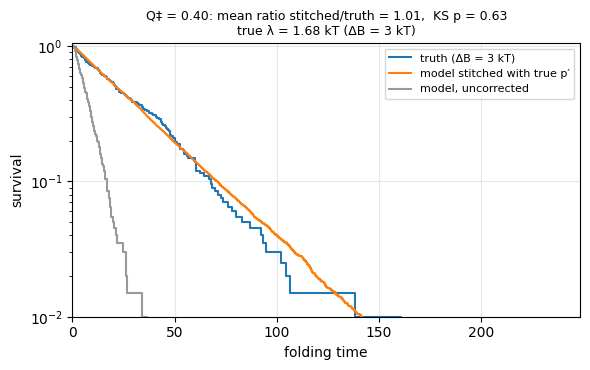

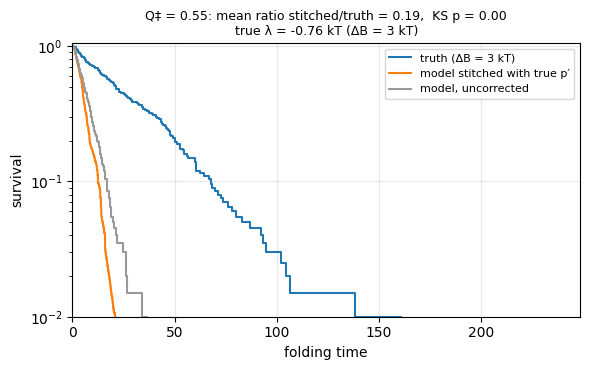

In [8]:
def show_validation(dB=3.0, qts=0.40):
    Am = mp.attempts(VAL["model"], qts, 0.0, False)
    At = mp.attempts(VAL[dB], qts, 0.0, False)
    pm, pt = mp.success_prob(Am["k"], Am["done"]), mp.success_prob(At["k"], At["done"])
    lam_true = np.log(pm / (1 - pm)) - np.log(pt / (1 - pt))
    ts = mp.stitch(pt, Am["fail_pool"], Am["succ_pool"], 10000, np.random.default_rng(0))
    Tt = At["T"][At["done"]]
    fig, ax = plt.subplots(figsize=(6, 3.8))
    for data, lab in [(Tt, f"truth (ΔB = {dB:g} kT)"), (ts, "model stitched with true p′")]:
        s = np.sort(data)
        ax.step(s, 1 - np.arange(1, s.size + 1) / s.size, where="post", label=lab)
    Tm = np.sort(Am["T"][Am["done"]])
    ax.step(Tm, 1 - np.arange(1, Tm.size + 1) / Tm.size, where="post", color="0.6", label="model, uncorrected")
    ax.set_yscale("log"); ax.set_ylim(1e-2, 1.05); ax.set_xlim(0, 1.2 * Tt.max())
    ax.set_xlabel("folding time"); ax.set_ylabel("survival")
    ax.set_title(f"Q‡ = {qts:.2f}: mean ratio stitched/truth = {ts.mean() / Tt.mean():.2f},  "
                 f"KS p = {stats.ks_2samp(ts, Tt).pvalue:.2f}\ntrue λ = {lam_true:.2f} kT "
                 f"(ΔB = {dB:g} kT)", fontsize=9)
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

explore(show_validation,
        static=[dict(dB=3.0, qts=0.40), dict(dB=3.0, qts=0.55)],
        dB=[2.0, 3.0],
        qts=(0.32, 0.70, 0.01) if HAVE_WIDGETS else None)

### 5b. Original vs stitched CDF

The same comparison as a cumulative distribution. Black is the original low-barrier model; colour is the stitched CDF at the chosen λ; grey dotted is the 3 kT ground truth. Three panels:
- **Absolute time.** λ moves the CDF to longer times. At the true λ (≈ 1.68 kT at Q‡ = 0.40) it lies on the truth.
- **Time scaled by the mean.** Only the shape remains. The shapes converge to the exponential well before the timescale is right, which is why λ_min is only a lower bound.
- **CDF minus the exponential CDF.** The largest absolute value is the KS statistic. The original model lies below zero at short times: it folds less often early on than a Poisson process would, which is the lag from the missing barrier and the initial relaxation.
- **Log time axis.** The lag has not gone away: no folding event is shorter than the time to leave U and cross (about 0.5–1 here), in the stitched data as in the truth. It stays fixed in absolute time while the barrier moves the bulk of the distribution to longer times, so relative to ⟨t⟩ it shrinks (from about 13% to 2%). That is where two-state kinetics comes from: a fixed dead time plus a long, memoryless wait.

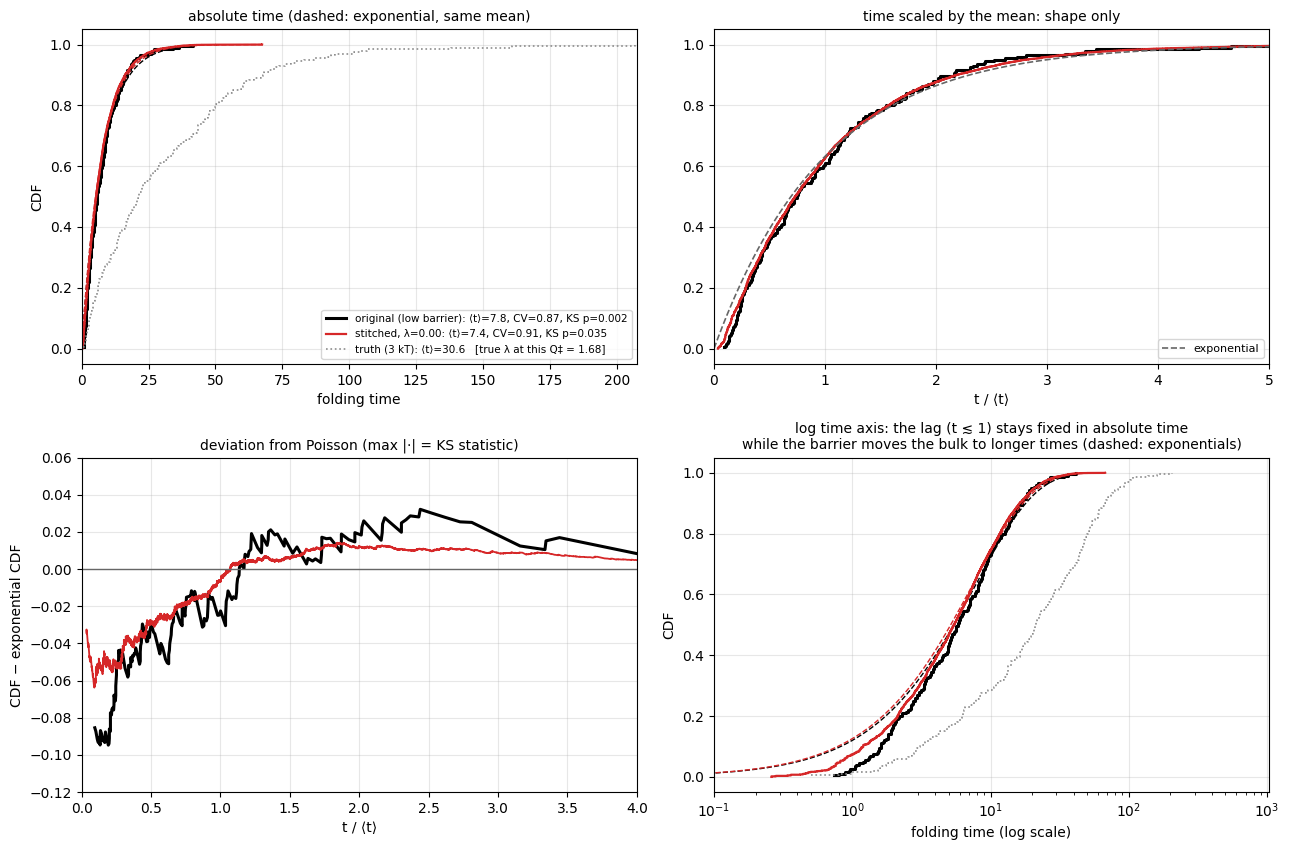

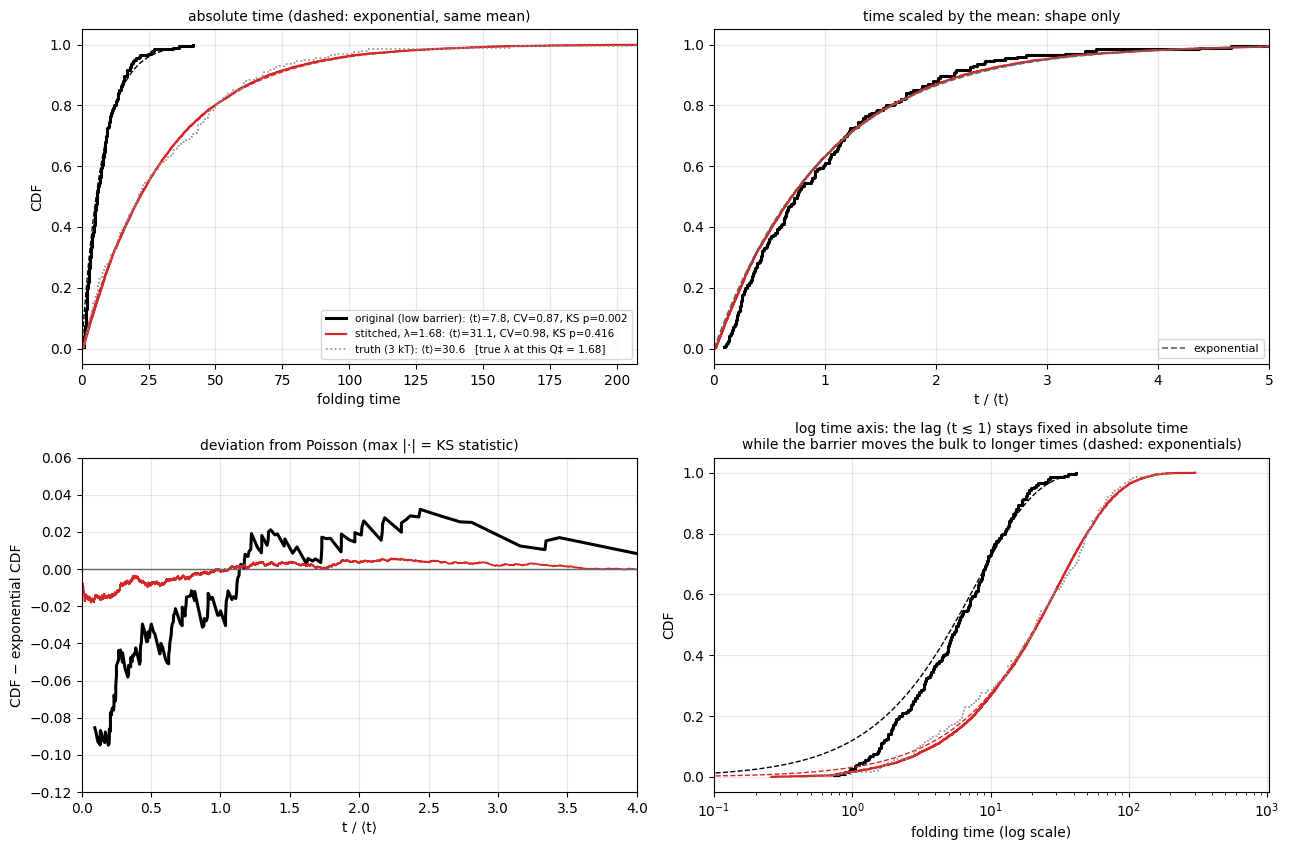

In [9]:
def show_cdf(lam=1.68, qts=0.40):
    A = mp.attempts(VAL["model"], qts, 0.0, False)
    At = mp.attempts(VAL[3.0], qts, 0.0, False)
    p = mp.success_prob(A["k"], A["done"])
    pt = mp.success_prob(At["k"], At["done"])
    lam_true = np.log(p / (1 - p)) - np.log(pt / (1 - pt))
    T0 = A["T"][A["done"]]
    Tt = At["T"][At["done"]]
    rng = np.random.default_rng(1)
    ts = mp.stitch(mp.tilted_p(p, lam), A["fail_pool"], A["succ_pool"], 10000, rng)
    null = mp.null_D(T0.size)
    sub = rng.choice(ts, size=(200, T0.size))
    ksp_st = np.median((np.sum(null[None, :] >= mp.D_rows(sub)[:, None], axis=1) + 1) / (null.size + 1))
    ksp_0 = mp.lilliefors_p(mp.D_rows(T0[None, :])[0], T0.size)

    fig, axs = plt.subplots(2, 2, figsize=(13, 8.6)); axs = axs.ravel()
    curves = [(T0, "k", 2.2, f"original (low barrier): ⟨t⟩={T0.mean():.1f}, CV={T0.std()/T0.mean():.2f}, KS p={ksp_0:.3f}"),
              (ts, "C3", 1.6, f"stitched, λ={lam:.2f}: ⟨t⟩={ts.mean():.1f}, CV={ts.std()/ts.mean():.2f}, KS p={ksp_st:.3f}")]
    for t, c, lw, lab in curves:
        srt = np.sort(t); F = np.arange(1, srt.size + 1) / srt.size; tau = t.mean()
        axs[0].step(srt, F, where="post", color=c, lw=lw, label=lab)
        x = np.linspace(0, srt.max(), 300); axs[0].plot(x, 1 - np.exp(-x / tau), "--", color=c, lw=1)
        axs[1].step(srt / tau, F, where="post", color=c, lw=lw)
        axs[2].plot(srt / tau, F - (1 - np.exp(-srt / tau)), color=c, lw=lw if lw > 2 else 1.3)
        axs[3].step(srt, F, where="post", color=c, lw=lw)
        xl = np.logspace(-2, np.log10(srt.max()), 300)
        axs[3].plot(xl, 1 - np.exp(-xl / tau), "--", color=c, lw=1)
    axs[0].step(np.sort(Tt), np.arange(1, Tt.size + 1) / Tt.size, where="post", color="0.55", ls=":", lw=1.2,
                label=f"truth (3 kT): ⟨t⟩={Tt.mean():.1f}   [true λ at this Q‡ = {lam_true:.2f}]")
    x = np.linspace(0, 6, 300); axs[1].plot(x, 1 - np.exp(-x), "--", color="0.4", lw=1.2, label="exponential")
    axs[0].set_xlim(0, 1.5 * np.percentile(Tt, 99))   # fixed by the truth: only the stitched curve moves with λ
    axs[0].set_xlabel("folding time"); axs[0].set_ylabel("CDF"); axs[0].legend(fontsize=7.5, loc="lower right")
    axs[0].set_title("absolute time (dashed: exponential, same mean)", fontsize=10)
    axs[1].set_xlim(0, 5); axs[1].set_xlabel("t / ⟨t⟩"); axs[1].legend(fontsize=8, loc="lower right")
    axs[1].set_title("time scaled by the mean: shape only", fontsize=10)
    axs[2].axhline(0, color="0.4", lw=1); axs[2].set_xlim(0, 4); axs[2].set_ylim(-0.12, 0.06)
    axs[2].set_xlabel("t / ⟨t⟩"); axs[2].set_ylabel("CDF − exponential CDF")
    axs[2].set_title("deviation from Poisson (max |·| = KS statistic)", fontsize=10)
    axs[3].step(np.sort(Tt), np.arange(1, Tt.size + 1) / Tt.size, where="post", color="0.55", ls=":", lw=1.2)
    axs[3].set_xscale("log"); axs[3].set_xlim(0.1, 5 * Tt.max())   # fixed, independent of λ
    axs[3].set_xlabel("folding time (log scale)"); axs[3].set_ylabel("CDF")
    axs[3].set_title("log time axis: the lag (t ≲ 1) stays fixed in absolute time\n"
                     "while the barrier moves the bulk to longer times (dashed: exponentials)", fontsize=10)
    plt.tight_layout(); plt.show()

explore(show_cdf, static=[dict(lam=0.0), dict(lam=1.68)],
        lam=(0.0, 3.0, 0.05) if HAVE_WIDGETS else None,
        qts=(0.32, 0.50, 0.01) if HAVE_WIDGETS else None)

## 6. Joint mode: forward and backward at the same temperature

Here the double well is asymmetric (ΔG ≈ −0.6 kT). Forward runs start in A and stop in B; backward runs do the reverse. Two relations hold at equilibrium (README §6):
- **Kinetic ΔG equals equilibrium ΔG**: $-kT\ln(M_{BA}/M_{AB}) = \Delta G$.
- **Transition paths are time-reversal symmetric**: forward and backward durations have the same distribution.

The temperature of the backward set is adjustable. At `Tr = 1` both relations hold. At `Tr > 1` the durations separate, which is how the script detects data wrongly declared as "same temperature".

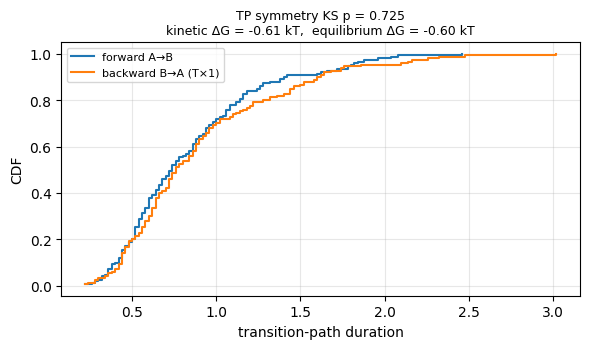

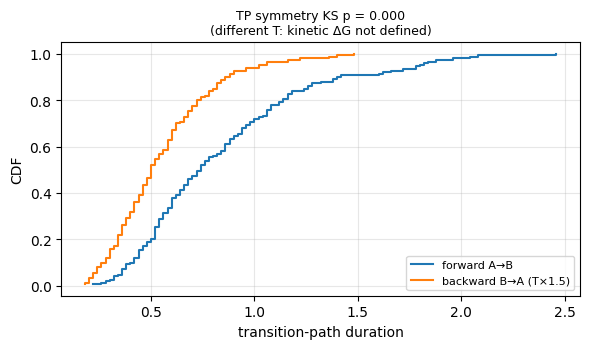

In [10]:
POT = dict(B=1.0, tilt=-1.0, sigma=0.06)
KWJ = dict(dt=0.002, stride=10, **POT)
_Qf, dtj = simulate("joint_fwd", n=150, seed=1, q0=0.2, **KWJ)
FWD = mj.direction(mj.build([(str(i), q, dtj, None) for i, q in enumerate(_Qf)], QU, QF, 1),
                   QU, QF, 0.4, 0.55, type("a", (), dict(t0=0.0, include_initial=False))())
_BWD_CACHE = {}

def show_joint(Tr=1.0):
    key = round(Tr, 2)
    if key not in _BWD_CACHE:
        Qb, _ = simulate(f"joint_bwd_T{Tr:g}", n=150, seed=2, q0=0.9, stop_below=0.25, Tr=Tr, **KWJ)
        _BWD_CACHE[key] = mj.direction(mj.build([(str(i), q, dtj, None) for i, q in enumerate(Qb)],
                                                -QF, -QU, -1), -QF, -QU, -0.7, -0.55,
                                       type("a", (), dict(t0=0.0, include_initial=False))())
    B = _BWD_CACHE[key]
    dG_kin = -np.log(B["M0"] / FWD["M0"])
    dG_eq = L.delta_G_eq(QU, QF, **POT)
    ks = stats.ks_2samp(FWD["tp_dur"], B["tp_dur"]).pvalue
    fig, ax = plt.subplots(figsize=(6, 3.6))
    for D, lab in [(FWD, "forward A→B"), (B, f"backward B→A (T×{Tr:g})")]:
        d = np.sort(D["tp_dur"]); ax.step(d, np.arange(1, d.size + 1) / d.size, where="post", label=lab)
    ax.set_xlabel("transition-path duration"); ax.set_ylabel("CDF"); ax.legend(fontsize=8)
    title = f"TP symmetry KS p = {ks:.3f}"
    if Tr == 1.0:
        title += f"\nkinetic ΔG = {dG_kin:.2f} kT,  equilibrium ΔG = {dG_eq:.2f} kT"
    else:
        title += "\n(different T: kinetic ΔG not defined)"
    ax.set_title(title, fontsize=9); plt.tight_layout(); plt.show()

explore(show_joint, static=[dict(Tr=1.0), dict(Tr=1.5)],
        Tr=[1.0, 1.25, 1.5, 2.0])

## 7. Where is the transition state? (README §2.10)

The tilt fixes *how much* barrier is missing (r = p′/p), but not *where* it sits. That location is an assumption, set by `--barrier-q` in the script and expressed as a value q* of the **model** committor. For a narrow missing barrier on the surface q_m = q*, the corrected committor is

$$q' = r\,q_m \;\text{(U side)},\qquad 1-q' = r\,(1-q_m)\;\text{(F side)},$$

and the transition state is where q′ = 1/2. Move λ and q* and watch three things:
- **q* = 0.5 (the default, barrier on the model TS):** the TS never moves.
- **q* ≠ 0.5:** the TS slides toward the barrier as λ grows, and sits on it once the tilt is strong enough.
- **Checked against the truth:** the dashed curve is the committor estimated from the higher-barrier ground truth of section 5.

model committor at the bump (Q = 0.55): q* = 0.51;  true λ = 1.68 kT


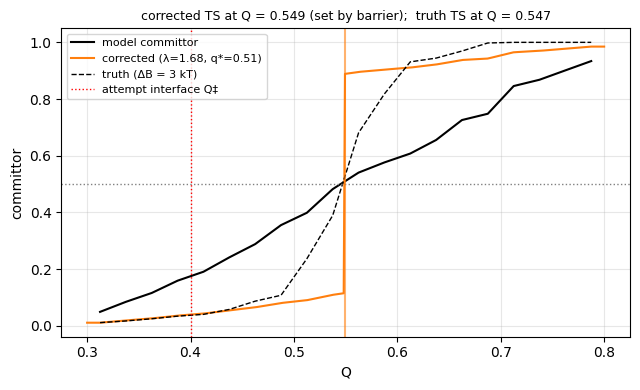

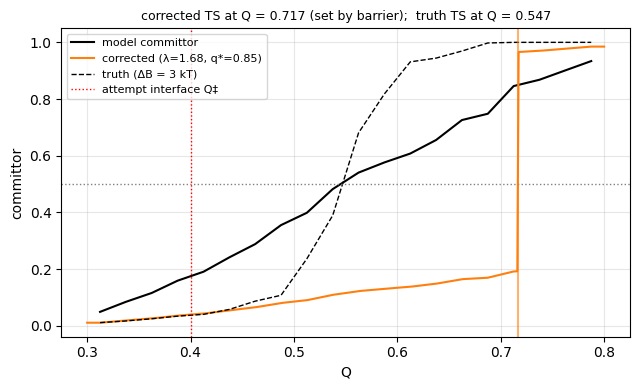

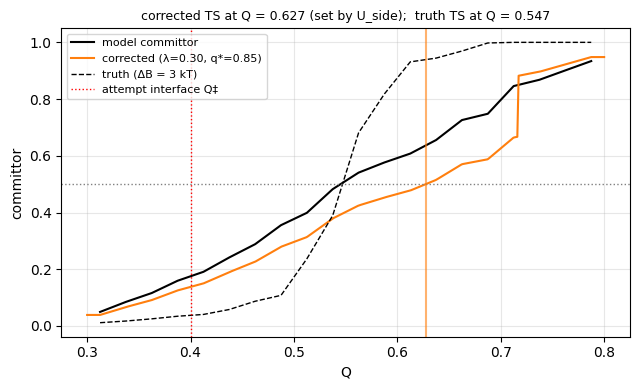

In [11]:
_, _, qv_m, oc_m = mp.committor_frames(VAL["model"], QU, QF)
CEN, _, RAW, ISO = mp.committor_profile(qv_m, oc_m, QU, QF, 20)
_, _, qv_t, oc_t = mp.committor_frames(VAL[3.0], QU, QF)
_, _, _, ISO_T = mp.committor_profile(qv_t, oc_t, QU, QF, 20)
QTS_V = 0.40
Am = mp.attempts(VAL["model"], QTS_V, 0.0, False)
P_M = mp.success_prob(Am["k"], Am["done"])
At = mp.attempts(VAL[3.0], QTS_V, 0.0, False)
LAM_TRUE = np.log(P_M / (1 - P_M)) - np.log(mp.success_prob(At["k"], At["done"]) / (1 - mp.success_prob(At["k"], At["done"])))
Q_STAR_BUMP = float(np.interp(0.55, CEN, ISO))
print(f"model committor at the bump (Q = 0.55): q* = {Q_STAR_BUMP:.2f};  true λ = {LAM_TRUE:.2f} kT")

def show_ts(lam=1.68, qstar=0.5):
    r = mp.tilted_p(P_M, lam) / P_M
    grid = np.linspace(QU, QF, 400)
    ok = np.isfinite(ISO)
    qm = np.interp(grid, CEN[ok], ISO[ok])
    qc = mp.corrected_committor(qm, r, qstar)
    qts, where = mp.ts_location(CEN, ISO, r, qstar)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(CEN, ISO, "k-", label="model committor")
    ax.plot(grid, qc, "C1", label=f"corrected (λ={lam:.2f}, q*={qstar:.2f})")
    ax.plot(CEN, ISO_T, "k--", lw=1, label="truth (ΔB = 3 kT)")
    ax.axhline(0.5, color="0.5", ls=":", lw=1)
    ax.axvline(QTS_V, color="r", ls=":", lw=1, label="attempt interface Q‡")
    if np.isfinite(qts):
        ax.axvline(qts, color="C1", lw=1.5, alpha=0.6)
    ax.set_xlabel("Q"); ax.set_ylabel("committor"); ax.legend(fontsize=8, loc="upper left")
    ax.set_title(f"corrected TS at Q = {qts:.3f} (set by {where});  truth TS at Q = "
                 f"{mp.q_at(CEN, ISO_T, 0.5):.3f}", fontsize=9)
    plt.tight_layout(); plt.show()

explore(show_ts,
        static=[dict(lam=round(float(LAM_TRUE), 2), qstar=round(Q_STAR_BUMP, 2)),
                dict(lam=round(float(LAM_TRUE), 2), qstar=0.85), dict(lam=0.3, qstar=0.85)],
        lam=(0.0, 4.0, 0.05) if HAVE_WIDGETS else None,
        qstar=(0.2, 0.9, 0.01) if HAVE_WIDGETS else None)

## 8. The (Q‡, λ) decision map

The script's `heatmap.png` collects the stitching test over **both** choices at once: the attempt interface Q‡ and the tilt λ. Colour is the median KS p-value, hatched cells pass the Poisson criterion, and triangles mark λ_min(Q‡).

Because the tilt acts only after an attempt passes Q‡, the **true TS lies between Q‡ and Qf**. Q‡ values at or beyond the (assumed) barrier are therefore invalid, and they are shaded. Move `qstar` to change the assumed barrier location, and with it the valid region.

On this validation data we also know the answer: the white line is the **true λ(Q‡)** from the higher-barrier ground truth. Two things to notice:
- **A lower bound.** λ_min sits well below the true λ on the plateau at low Q‡, as it should.
- **Validity ends at the foot of the barrier, not at its centre.** The true λ starts dropping once Q‡ enters the bump (from Q ≈ 0.45, while the bump is centred at 0.55), and λ_min rises there. The shaded boundary is therefore only an upper limit. In real data, where the true λ is unknown, the observable signal is a **rise of λ_min** above its low-Q‡ level: use the flat part before it.
- **Blind to the location.** The map cannot tell *where* beyond Q‡ the barrier is; that information is not in the folding times (README §2.8).

computing the decision map (17 x 17 stitching tests, a few seconds)…


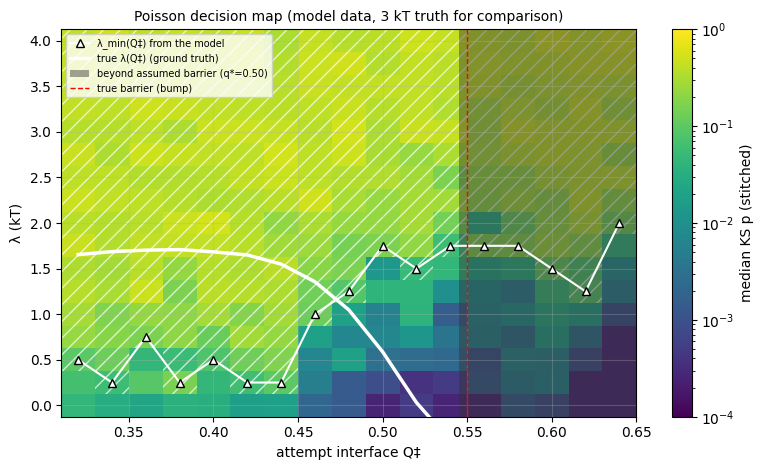

In [12]:
print("computing the decision map (17 x 17 stitching tests, a few seconds)…", flush=True)
QG = np.round(np.arange(0.32, 0.66, 0.02), 3)
LG = np.linspace(0, 4, 17)
class _A: t0 = 0.0; include_initial = False; nstitch = 2000; nsub = 100; alpha = 0.05; cv_tol = 0.1
KSP, CVH = mp.ks_heatmap(VAL["model"], QG, LG, _A, np.random.default_rng(0))
PASS = (KSP >= 0.05) & (np.abs(CVH - 1) <= 0.1)
LMIN = [LG[np.argmax(PASS[i])] if PASS[i].any() else np.nan for i in range(QG.size)]
def _p(tr, q):
    A = mp.attempts(tr, q, 0.0, False); return mp.success_prob(A["k"], A["done"])
LTRUE = [np.log(_p(VAL["model"], q) / (1 - _p(VAL["model"], q))) - np.log(_p(VAL[3.0], q) / (1 - _p(VAL[3.0], q)))
         for q in QG]

def show_heatmap(qstar=0.5):
    from matplotlib.colors import LogNorm
    from matplotlib.patches import Rectangle
    dq, dl = QG[1] - QG[0], LG[1] - LG[0]
    qe, le = np.r_[QG - dq / 2, QG[-1] + dq / 2], np.r_[LG - dl / 2, LG[-1] + dl / 2]
    fig, ax = plt.subplots(figsize=(8, 4.8))
    im = ax.pcolormesh(qe, le, np.clip(KSP.T, 1e-4, 1), norm=LogNorm(1e-4, 1), cmap="viridis")
    fig.colorbar(im, ax=ax, label="median KS p (stitched)")
    for i, j in zip(*np.nonzero(PASS)):
        ax.add_patch(Rectangle((qe[i], le[j]), dq, dl, fill=False, hatch="//", edgecolor="white", lw=0, alpha=0.7))
    ax.plot(QG, LMIN, "w^-", mec="k", label="λ_min(Q‡) from the model")
    ax.plot(QG, LTRUE, "-", color="white", lw=2.5, label="true λ(Q‡) (ground truth)")
    qb = mp.q_at(CEN, ISO, qstar)
    ax.axvspan(qb, qe[-1], color="0.2", alpha=0.45, lw=0, label=f"beyond assumed barrier (q*={qstar:.2f})")
    ax.axvline(0.55, color="r", ls="--", lw=1, label="true barrier (bump)")
    ax.set_xlim(qe[0], qe[-1]); ax.set_ylim(le[0], le[-1])
    ax.set_xlabel("attempt interface Q‡"); ax.set_ylabel("λ (kT)"); ax.legend(fontsize=7, loc="upper left")
    ax.set_title("Poisson decision map (model data, 3 kT truth for comparison)", fontsize=10)
    plt.tight_layout(); plt.show()

explore(show_heatmap, static=[dict(qstar=0.5)], qstar=(0.2, 0.9, 0.01) if HAVE_WIDGETS else None)

## Where to go from here

- Run the command-line tools on these datasets and compare their `summary.csv` or `joint_summary.json` with what you see here (each step of this notebook is one executable: stitching, reweighting, committor/TS):
  ```bash
  maxcal-stitch "data/*.xvg" --qu 0.3 --qf 0.8 --qts 0.4 --out stitch_out
  maxcal-reweight "data/*.xvg" --qu 0.3 --qf 0.8 --qts 0.4 --out reweight_out
  maxcal-committor "data/*.xvg" --qu 0.3 --qf 0.8 --qts 0.4 --out committor_out
  ```
- Replace the Langevin trajectories with your own `Q(t)` files by loading them with `mp.load_traj` and `to_trajs`.